# Solution for Lab Activity 03

The first thing we want to do, as we do for all of our lab activities, is import the Python libraries we need to use, and then read in both the penguins and bike sharing datasets. 

In [1]:
# Import necessary Python packages. 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

# Read in the Penguin dataset
peng = pd.read_csv("../../data/penguins.csv")

# Read in the bikes dataset
bike = pd.read_csv("../../data/bike-sharing-daily.csv", parse_dates=["dteday"])

In [2]:
# Now we will drop the rows of the penguins dataset that do not have information for flipper length, body mass, bill length, and bill depth
peng_clean = peng.dropna(subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]).reset_index(drop=True)

# Optionally, we can check the shape of our dataframe to ensure we have the right number of rows. (Expected based on previous work)
peng_clean.shape

(342, 8)

## Part 1: Multicollinearity and Multiple Linear Regression

### Q1: Looking again at Part 4b from Last Week's Lab Activity

In last week's Lab Activity, I asked you to build three different models to predict penguin body mass and compare them using $R^2$, Adjusted $R^2$, and the F-statistic for each individual model. This week, I want you to build the same three models, but this time, use the nested F-statistic, and anova_lm functionality we discussed this week in class. The code for this is below.  

In [3]:
# Again, we will build the same three models we did last time. 

# This is an array. Each element of the array is a list of features that we want to use in each model. 
# Note that they are additive. 


specs = [
    ["flipper_length_mm"],
    ["flipper_length_mm", "bill_depth_mm"],
    ["flipper_length_mm", "bill_depth_mm", "bill_length_mm"],
]

fitted_models = []
rows = []
# This loop goes through each of the different sets of parameters
for cols in specs:
    # This is the line that builds the linear model using OLS for each set of features. 
    m = sm.OLS(peng_clean["body_mass_g"], sm.add_constant(peng_clean[cols])).fit()
    fitted_models.append(m)
    rows.append({"predictors": " + ".join(c.replace("_mm", "") for c in cols),
                 "d": len(cols), "R^2": m.rsquared, "Adj R^2": m.rsquared_adj,
                 "RSE": np.sqrt(m.scale), "F": m.fvalue})
pd.DataFrame(rows).set_index("predictors").round(4)

,d,R^2,Adj R^2,RSE,F
predictors,,,,,
flipper_length,1,0.7590,0.7583,394.2782,1070.7446
flipper_length + bill_depth,2,0.7610,0.7596,393.1784,539.8239
flipper_length + bill_depth + bill_length,3,0.7615,0.7594,393.4048,359.6718


In [4]:
# The table above gives the relevant parameters for each individual model. 
# Now we will use the anova_lm function to compare each of these models using the nested F-statistic
# This does the F-test described on slide 32 of the Week 4 slide deck. 
# It explicitly looks at the impact of adding another term. 

compare_models = sm.stats.anova_lm(fitted_models[0], fitted_models[1], fitted_models[2])
compare_models

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,340.0,5.285480e+07,0.0,NaN,NaN,NaN
1,339.0,5.240575e+07,1.0,449043.646743,2.901411,0.089419
2,338.0,5.231136e+07,1.0,94393.101155,0.609903,0.435371


The output of the code above indicates that adding bill depth is not significant ($F=2.9$, p=0.089) and adding bill_length really doesn't add much value to the predictive model. Last week, when we looked only at $R^2$, Adjusted $R^2$, and the F-statistic for each model, we concluded that the second model (with bill depth) was modestly better than the first one (flipper length only), but that either model 1 or model 2 would be an acceptable choice. This analysis suggests that model 1 is the best choice, though choosing model 2 could still be defensible. 

### Q2 Looking at bike data and exploring multi-collinearity and multiple linear regression

Part a. Look at the correlation matrix for cnt, temp, hum, windspeed. Here, we will look both at the numbers, and a heatmap, which is a different visualization 

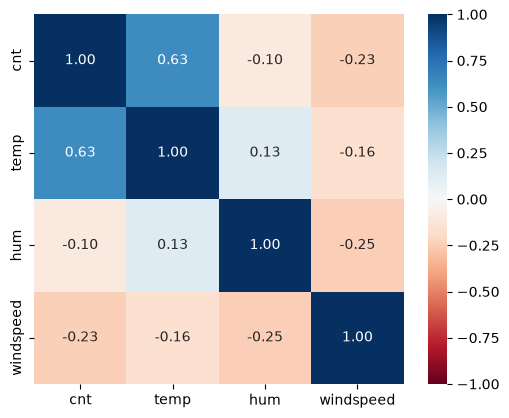

In [5]:
# 2a Correlation and Heatmap
bike_corr = bike[["cnt", "temp", "hum", "windspeed"]].corr()
sns.heatmap(bike_corr, cmap=plt.get_cmap("RdBu"), vmin=-1, vmax=1,
            square=True, annot=True, fmt=".2f")
plt.show()

We can see from the above correlation plot that temp is most correlated with the number of daily bike rentals. In part b, below, we are going to look at VIF in order to better understand the relationship among these predictors. 

**Q2 Part B** Build a linear model predicting bike rentals as a function of temp (temperature), hum (humidity), and windspeed. We will calculate the VIF, and based on VIF and the correlation plot above, we can start to understand how each of these features impact the number of bikes rented.  


In [6]:
cnt_model1 = sm.OLS(bike["cnt"], sm.add_constant(bike[["temp", "hum", "windspeed"]])).fit()
X = sm.add_constant(bike[["temp", "hum", "windspeed"]])
pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
          index=["temp", "hum", "windspeed"])

temp         1.034283
hum          1.074850
windspeed    1.084580
dtype: float64

In [7]:
print(cnt_model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        11:21:21   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4084.3634    337.862     12.089      0.0

Based on the calculation above, temp, humidity, and windspeed have low enough variance inflation factors (below 5) that we can include all of them in the model without having to worry about multi-collinearity. 

As for the second part of the question: Describe how each feature impacts the count of bikes rented, we can look at the correlation matrix that we generated in Part a. 

* The correlation between temp and cnt is 0.63, which is positive, and higher than the correlation between cnt and the other two variables. The positive value means that as temperature goes up, the count of bikes rented will also go up. This makes intuitive sense; people are more likely to want to ride bikes when the weather is warmer. The fact that 0.63 is higher than the other values in the correlation matrix suggests that temperature is more impactful in the count of bikes rented than either of the two variables. This is also borne out from the model coefficients themselves. 


* Both humidity and windspeed have negative values. This means that as humidity and windspeed go up, the number of bikes rented goes down. This also makes intuitive sense. Windy or humid days make for less pleasant bike riding! 


**Q2 Part c** Now, we will use the same code as we did for the penguins in Q1, to build three models predicting count, and then comparing them using a nested F-test. 

In [8]:
# Again, we will build the same three models we did last time. 

# This is an array. Each element of the array is a list of features that we want to use in each model. 
# Note that they are additive. 
specs = [
    ["temp"],
    ["temp", "hum"],
    ["temp", "hum", "windspeed"],
]

fitted_models = []
rows = []
# This loop goes through each of the different sets of parameters
for cols in specs:
    # This is the line that builds the linear model using OLS for each set of features. 
    m = sm.OLS(bike["cnt"], sm.add_constant(bike[cols])).fit()
    fitted_models.append(m)
    rows.append({"predictors": " + ".join(c.replace("_mm", "") for c in cols),
                 "d": len(cols), "R^2": m.rsquared, "Adj R^2": m.rsquared_adj,
                 "RSE": np.sqrt(m.scale), "F": m.fvalue})
pd.DataFrame(rows).set_index("predictors").round(4)

,d,R^2,Adj R^2,RSE,F
predictors,,,,,
temp,1,0.3937,0.3929,1509.3885,473.4717
temp + hum,2,0.4268,0.4252,1468.6764,271.0307
temp + hum + windspeed,3,0.4609,0.4587,1425.3054,207.1771


In [9]:
# Now we will compare all three models
sm.stats.anova_lm(fitted_models[0], fitted_models[1], fitted_models[2])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,729.0,1.660847e+09,0.0,NaN,NaN,NaN
1,728.0,1.570304e+09,1.0,9.054330e+07,44.569779,4.869005e-11
2,727.0,1.476897e+09,1.0,9.340630e+07,45.979085,2.475445e-11


**Q2 Part d** Based on the tables above, one looking at $R^2$, Adjusted $R^2$, and F for each individual model, as well as the anova comparing them, I would choose the model with all three predictors. It has the highest $R^2$ and Adjusted $R^2$ values. In addition, the output of the anova shows that adding each additional term is significant. 

## Part 2: Categorical Predictors and Interaction Terms

This portion of the lab is intended to help further practice how to use categorical predictors and think about interaction terms. We will again be using the penguins data, but instead of looking at Species, we will look at Sex (ie whether the penguin is male vs female.)

### Q1 

In Q1, we want to explore the impact of removing 9 additional penguins from this data set. Recall that when we look only at bill length, flipper length, and bill depth as predictors, we only need to remove 2 penguins from the dataset that are missing this data. There are 9 additional penguins with sex as a missing variable, and we need to remove those in order to build models with sex as one of the regressor. 

The first part of this question is to remove these 9 penguins, build the same model that you did previously (without including sex) and look at the difference in results. This is less about understanding the impact of sex (that will come in subsequent questions) but understanding the impact of removing these 9 penguins. 

In [10]:
# First, we are going to create another dataset that drops all penguins that have any of these variables missing. 
# Recall that the dataset we used previously is peng_clean
peng_no_na = peng.dropna(subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm", "sex"]).reset_index(drop=True)

# There are 333 rows in this new dataset instead of 342. 
peng_no_na.shape

(333, 8)

In [11]:
# Now let's build and compare both models. 
cols = ["flipper_length_mm", "bill_depth_mm", "bill_length_mm"]

datasets = {"peng_clean": peng_clean, "peng_no_na": peng_no_na}

rows = []
for name, df in datasets.items():
    m = sm.OLS(df["body_mass_g"], sm.add_constant(df[cols])).fit()
    rows.append({"dataset": name,
                 "n": int(m.nobs),
                 "R^2": m.rsquared,
                 "Adj R^2": m.rsquared_adj,
                 "RSE": np.sqrt(m.scale),
                 "F": m.fvalue})

pd.DataFrame(rows).set_index("dataset").round(4)

,n,R^2,Adj R^2,RSE,F
dataset,,,,,
peng_clean,342,0.7615,0.7594,393.4048,359.6718
peng_no_na,333,0.7639,0.7618,393.0046,354.8980


**Q1 continued** As we can see from the table above, including or removing these 9 penguins does not meaningfully impact the $R^2$, Adjusted $R^2$, or F-statistic. 

Note: I did not do an ```anova_lm``` here because we are comparing datasets with different number of samples, so this comparison does not make sense. We will look more specifically at these data points as outliers in Part 3 of this lab. 

### Q2 Including sex as a predictor

In this section of the lab, we are going to include sex as a categorical variable, looking at both additive and interactive effects. 

In [12]:
# First, we will build three models and compare them. 
flipper_only = smf.ols("body_mass_g ~ flipper_length_mm", data=peng_no_na).fit()
flipper_sex_additive = smf.ols("body_mass_g ~ flipper_length_mm + C(sex)", data=peng_no_na).fit()
flipper_sex_interaction = smf.ols("body_mass_g ~ flipper_length_mm * C(sex)", data=peng_no_na).fit()
sm.stats.anova_lm(flipper_only, flipper_sex_additive, flipper_sex_interaction)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,331.0,5.121196e+07,0.0,NaN,NaN,NaN
1,330.0,4.179537e+07,1.0,9.416589e+06,74.126700,3.050629e-16
2,329.0,4.179409e+07,1.0,1.286001e+03,0.010123,9.199177e-01


In [13]:
# The above table suggests that the model with the additive term is the best one. 
# Let's also look at the R^2, Adj. R^2, RSE, and F-statistic for each model

models = {
    "flipper_only": flipper_only,
    "flipper + sex": flipper_sex_additive,
    "flipper * sex": flipper_sex_interaction,
}

rows = []
for name, m in models.items():
    rows.append({"model": name,
                 "k": int(m.df_model),
                 "R^2": m.rsquared,
                 "Adj R^2": m.rsquared_adj,
                 "RSE": np.sqrt(m.scale),
                 "F": m.fvalue})

pd.DataFrame(rows).set_index("model").round(3)

,k,R^2,Adj R^2,RSE,F
model,,,,,
flipper_only,1,0.762,0.761,393.343,1060.295
flipper + sex,2,0.806,0.805,355.883,684.803
flipper * sex,3,0.806,0.804,356.418,455.169


**Q2 continued**

a) Based on model statistics and anova comparison above, we can conclude that the best model is the second one

```flipper_sex_additive = smf.ols("body_mass_g ~ flipper_length_mm + C(sex)", data=peng_no_na).fit()```

When we include the additive effect of sex, the nested F-statistic in the anova is 74 and the associated p-value is extremely small $~10^{-16}$. The anova also demonstrates that the interaction term does not add value. 

Although the anova is fairly unequivocal, we can look at the individual statistics for each model, and this supports what we are seeing  with the anova. Including sex in the model improves the Adjusted $R^2$ (0.761 --> 0.805) and reduces the error (393.3 --> 355.9). The interaction term lowers the Adjusted $R^2$ and increases the error, suggesting that it does not add much value to the model. 

b) In order to answer the question, what is the impact of sex on body mass, I am going to look at the individual coefficients for the additive model, as well as generate a plot to help me better interpret the data. (Code below.) 

In [14]:
# Looking at individual coefficients
print(flipper_sex_additive.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          3.53e-118
Time:                        11:21:21   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.79

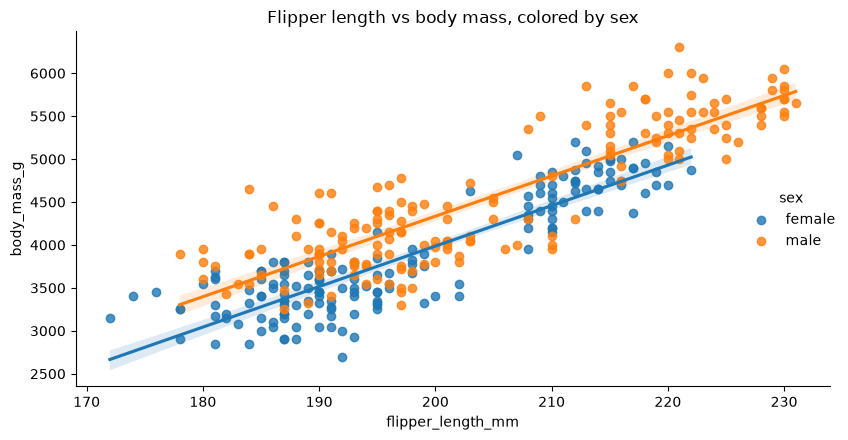

In [15]:
g = sns.lmplot(data=peng_no_na, x="flipper_length_mm", y="body_mass_g",
               hue="sex", hue_order=["female", "male"],
               height=4.5, aspect=7.5/4.5,
               scatter_kws={"alpha": 0.8}, ci=95)
g.ax.set_title("Flipper length vs body mass, colored by sex")
plt.tight_layout()

**Q2 b+c** 

Looking at the output from the flipper_sex_additive model, we can see that:
* Female is the reference level for this categorical predictor
* If we hold flipper length fixed, a male penguin is predicted to be about 348g heavier than a female penguin. We can tell this based on the coefficient for $C(sex)[T.male]$. The t-statistic and associated p-value indicate that this is significant. 

The plot above visually indicates that the slope (e.g. impact of flipper length) is constant for both sexes. I am using this plot to help validate and confirm the numbers that statsmodels is including in the model summary. 

### Q3: Two categorical variables

In this part of the question, we want to look at interaction terms when we have only categorical variables. To do this, we will predict penguin body mass as a function of sex and species, looking at additive and interactive effects. 

In [16]:
# Q3 part a
# Below are models of body mass as a function of C(sex) and C(species)
sex_and_species_additive = smf.ols("body_mass_g ~ C(sex) + C(species)", data=peng_no_na).fit()
sex_and_species_interaction = smf.ols("body_mass_g ~ C(sex)*C(species)", data=peng_no_na).fit()

sm.stats.anova_lm(sex_and_species_additive, sex_and_species_interaction)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,329.0,3.297919e+07,0.0,NaN,NaN,NaN
1,327.0,3.130263e+07,2.0,1.676557e+06,8.756997,0.000197


In [17]:
# Let's print the model summary of the interaction model, and look at the coefficients
print(sex_and_species_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     384.3
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.54e-134
Time:                        11:21:21   Log-Likelihood:                -2379.1
No. Observations:                 333   AIC:                             4770.
Df Residuals:                     327   BIC:                             4793.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

**Q3a+b**

a) Based on F-statistic in the above, we can see that the model with the interaction term is better. 

b) To interpret the coefficients, we can look at the model summary (above)

* The intercept is the average body mass of female Adelie penguins, since female is our reference level for sex, and Adelie is our reference level for species. 

* C(sex)[T.male] is how much bigger male Adelie penguins are than female Adelie penguins

* C(species)[T.Chinstrap] compares Chinstrap and Adelie females

* C(species)[T.Gentoo] compares Gentoo and Adelie females. 

* C(sex)[T.male]:C(species)[T.Chinstrap] is the coefficient that measures the difference in male-female gap between Adelies and Chinstraps. -262.9 means that the male female gap for Chinstrap penguins is smaller then the male-female gap for Adelies. The p-value of 0.004 means that this is a significant difference. 

* C(sex)[T.male]:C(species)[T.Gentoo] is the coefficient that measures the difference in male-female gap between Adelies and Gentoos. 130.4 means that the male female gap for Gentoo penguins is larger then the male-female gap for Adelies. The p-value of 0.089 means that this difference is not significant.


In [18]:
# If we wanted to check the above math, we could calculate mean body mass by species and sex. 
# An example for Adelie females is below. 
peng_no_na[(peng_no_na["species"] == "Adelie") & (peng_no_na["sex"] == "female")]["body_mass_g"].mean()

np.float64(3368.8356164383563)

**Q3 c**

In the plot below, we can visually confirm what the models above are telling us. While male penguins are larger than female penguins for all species, we can see visually that the difference between Chinstrap Male/Females is smaller than the difference for either Adelie or Gentoo. 

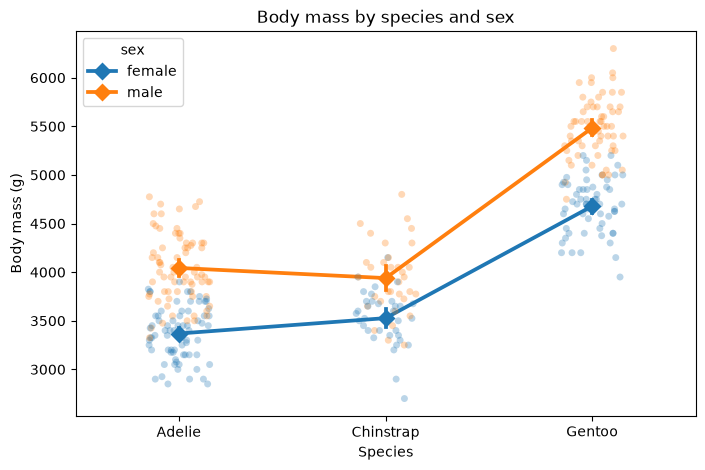

In [19]:
order = ["Adelie", "Chinstrap", "Gentoo"]
hue_order = ["female", "male"]

fig, ax = plt.subplots(figsize=(8, 5))

# Note that we are overlaying two plots below: 
# The stripplot shows individual data points
# The pointplot shows the averages with errorbars

sns.stripplot(data=peng_no_na, x="species", y="body_mass_g", hue="sex",
              order=order, hue_order=hue_order, alpha=0.3,
              jitter=0.15, legend=False, ax=ax)

sns.pointplot(data=peng_no_na, x="species", y="body_mass_g", hue="sex",
              order=order, hue_order=hue_order, errorbar=("ci", 95),
              markers="D", ax=ax)

ax.set_ylabel("Body mass (g)")
ax.set_xlabel("Species")
ax.set_title("Body mass by species and sex")
plt.show()

### Q4: Interaction terms in the bike rentals dataset

For this final part of the question, we are going to look at the bike dataset, and instead of predicting the total rental count, we are going to look at the count for both casual and registered riders. 

Note that working day is a binary variable. If the day is not a weekend or a holiday, it is assumed to be a working day. (1) Otherwise, it is 0 (not a working day.)

In [20]:
# Q4a Casual riders
casual_additive = smf.ols("casual ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
casual_interactive = smf.ols("casual ~ temp*C(workingday) + hum + windspeed", data=bike).fit()
sm.stats.anova_lm(casual_additive, casual_interactive)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,726.0,1.276423e+08,0.0,NaN,NaN,NaN
1,725.0,1.103186e+08,1.0,1.732378e+07,113.849712,8.681452e-25


In [21]:
# Q4b Registered riders

registered_additive = smf.ols("registered ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
registered_interactive = smf.ols("registered ~ temp * C(workingday) + hum + windspeed", data=bike).fit()
sm.stats.anova_lm(registered_additive, registered_interactive)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,726.0,1.020706e+09,0.0,NaN,NaN,NaN
1,725.0,1.016851e+09,1.0,3.855347e+06,2.748806,0.09776


**Qa+b+c**

What the model comparisons above are telling us is that for casual riders, the interactive model is significantly better than the additive model. For registered riders, the interaction between temp and working day does not significantly improve the model. 

To answer part c, what is this data telling us, we need to use the model summaries below. 

Note that the reference level for workingday is 0, meaning NOT a working day

* For casual bike riders, the p-value for C(workingday)[T.1] is not significant, but this coefficient only measures the working-day effect at temp=0, which is outside the range of our data. What is interesting here is the negative coefficient for the interaction term between temperature and working day. If it is a working day, the number of casual rentals increases less as temperature increases vs if it is not a working day. This makes intuitive sense. Folks who casually rent bikes are probably less likely to do so on a working day, even if the weather is warm. 
* For registered bike users, working day is significant. We can hypothesize that registered users are more likely to ride bikes on a working day. The fact that they are registered suggests that they are more frequent bike riders, and possibly more likely to ride on working days, maybe as part of a commute? 

In [22]:
print(casual_interactive.summary())

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     307.4
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          2.25e-176
Time:                        11:21:21   Log-Likelihood:                -5395.6
No. Observations:                 731   AIC:                         1.080e+04
Df Residuals:                     725   BIC:                         1.083e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [23]:
print(registered_additive.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     134.5
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           5.97e-86
Time:                        11:21:21   Log-Likelihood:                -6208.8
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     726   BIC:                         1.245e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286

**Q4d** Why did I ask you to build two separate models? 

Because the casual + registered = cnt. e.g. the total count of bike rentals is an exact combination of casual + registered. Both together would give an $R^2$ of 1. Modeling each group separately lets us see how working day and temperature affect the two kinds of riders in different ways. These different patterns would be blurred in a combined model. 

## Part 3: Outliers, Leverage, and Influence

In this part of the assignment, you should be able to use much of the code that we leveraged in class in the ```feat_selection_pt2_interactions_outliers.ipynb``` notebook. 

The goal of this section is to look a bit more at data points that are outliers, highly influential, or high leverage. Often times when we are doing analysis, there is not a one size fits all approach to handling these data points. The most important thing to remember is that we cannot just throw out data points to make our model fit better or because we don't like what they are telling us. Unless we can unequivocally determine that we have faulty equipment or there is a clear data entry error (e.g. if we saw a penguin that weighed 45,000g), usually we need to keep these data points in our model, and be clear about how they impact the conclusions we are making. 

### Q1

First, we will look at the penguins to determine if there are any outliers in the dataset, and how that might impact prediction. 

In [24]:
# Part a Build a dataframe to look at outliers in our original penguin model
# I am using the same code we did in class to generate this table
peng_orig = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm", data=peng_clean).fit()
infl = OLSInfluence(peng_orig)

# We also need to grab the number of observations and degrees of freedom
# Again, the code for this we went over in class
n, p = int(peng_orig.nobs), peng_orig.df_model
print(f"n = {n}, p = {p:.0f} ")

diag = pd.DataFrame({
    "actual_body_mass": peng_clean["body_mass_g"],
    "fitted":    peng_orig.fittedvalues,
    "residuals": peng_orig.resid,
    "student_resid": infl.resid_studentized_external,
    "leverage":  infl.hat_matrix_diag,
    "cooks_d":   infl.cooks_distance[0],
})

# Look at the first few rows
diag.head()

n = 342, p = 3 


,actual_body_mass,fitted,residuals,student_resid,leverage,cooks_d
0,3750.0,3211.617868,538.382132,1.376420,0.008831,0.004209
1,3800.0,3438.564312,361.435688,0.921907,0.007306,0.001564
2,3250.0,3906.346483,-656.346483,-1.676699,0.004599,0.003230
3,3450.0,3816.889879,-366.889879,-0.938715,0.013330,0.002977
4,3650.0,3702.967340,-52.967340,-0.135413,0.014287,0.000067


In [25]:
# Q1 Part b: The cutoffs we looked at in class came from the formulas in the associated slides for Week 4. 
# Specifically, we are looking at high leverage values and the Cook's D for influential values

lev_cut, cook_cut = 2 * (p + 1) / n, 4 / n
print(f"n = {n}, p = {p:.0f}   leverage cutoff = {lev_cut:.4f}   Cook's D cutoff = {cook_cut:.4f}")

# Count of observations that get flagged by each diagnostic
print(f"\noutliers   (|studentized resid| > 3): {(diag.student_resid.abs() > 3).sum()}")
print(f"high leverage (h > 2(p+1)/n):        {(diag.leverage > lev_cut).sum()}")
print(f"influential   (Cook's D > 4/n):      {(diag.cooks_d > cook_cut).sum()}")


n = 342, p = 3   leverage cutoff = 0.0234   Cook's D cutoff = 0.0117

outliers   (|studentized resid| > 3): 1
high leverage (h > 2(p+1)/n):        10
influential   (Cook's D > 4/n):      13


In [26]:
# Part b continued

# We can see from our calculations above that there is one outlier 10 high leverage points and 13 influential datapoints. 
# Let's look at each of the 9 penguins that are missing sex. Are they included here? 

# Let's first find all of the penguins that meet the above criteria in the original dataframe

# Flag each diagnostic in the diag dataframe (index matches peng_clean)
diag["outlier"]       = diag.student_resid.abs() > 3
diag["high_leverage"] = diag.leverage > lev_cut
diag["influential"]   = diag.cooks_d > cook_cut

# Keep only rows flagged by at least one diagnostic
flagged = diag[diag[["outlier", "high_leverage", "influential"]].any(axis=1)]

# Join the original penguin info with the diagnostics for those rows
flagged_penguins = peng_clean.loc[flagged.index].join(
    flagged[["fitted", "residuals", "student_resid", "leverage", "cooks_d",
             "outlier", "high_leverage", "influential"]]
)
flagged_penguins



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,fitted,residuals,student_resid,leverage,cooks_d,outlier,high_leverage,influential
13,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male,2007,4095.585324,304.414676,0.789511,0.040485,0.006582,False,True,False
30,Adelie,Dream,37.2,18.1,178.0,3900.0,male,2007,3040.873025,859.126975,2.209306,0.011716,0.014302,False,False,True
34,Adelie,Dream,39.2,21.1,196.0,4150.0,male,2007,4014.191255,135.808745,0.348894,0.023529,0.000735,False,True,False
38,Adelie,Dream,39.8,19.1,184.0,4650.0,male,2007,3373.358621,1276.641379,3.304865,0.007532,0.020133,True,False,True
89,Adelie,Dream,35.7,18.0,202.0,3550.0,female,2008,4239.086660,-689.086660,-1.774156,0.019076,0.015206,False,False,True
110,Adelie,Biscoe,45.6,20.3,191.0,4600.0,male,2009,3773.441171,826.558829,2.124718,0.011998,0.013565,False,False,True
116,Adelie,Torgersen,37.3,20.5,199.0,3775.0,male,2009,4145.061741,-370.061741,-0.953345,0.026688,0.006232,False,True,False
164,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,male,2007,4776.734805,1073.265195,2.767218,0.008897,0.016852,False,False,True
168,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,male,2007,5194.247755,1105.752245,2.853177,0.009035,0.018171,False,False,True
184,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,male,2007,5726.042842,323.957158,0.835670,0.029850,0.005377,False,True,False


**Q1 Part b + c**

b) Interestingly, none of the 9 penguins that are missing the sex variable are flagged in the above table. None of them are categorized as outliers, influential or high leverage. 

c) Nothing in the above table indicates that removing those 9 penguins would have a significant impact on any of the conclusions we drew previously.  


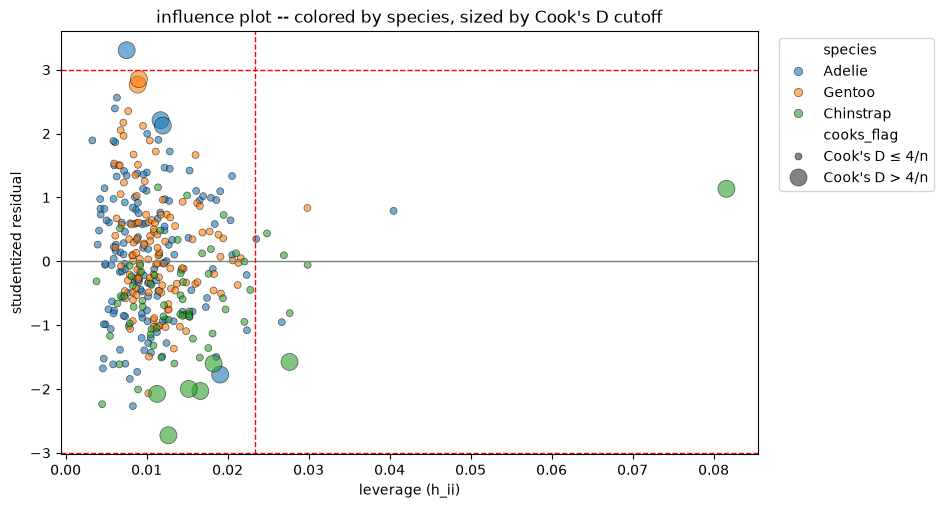

In [27]:
# Q1 Part d
# We can use the exact same code we used in class to generate this plot, but with two adjustments:
# First, we will color the circles by penguin species rather than Cook's D cutoff. 
# Second, we will make the circles larger for those penguins that exceed Cook's D cutoff. 

diag["species"] = peng_clean["species"]

diag["cooks_flag"] = np.where(diag.cooks_d > cook_cut, "Cook's D > 4/n", "Cook's D ≤ 4/n")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=diag, x="leverage", y="student_resid",
                hue="species", size="cooks_flag",
                sizes={"Cook's D ≤ 4/n": 25, "Cook's D > 4/n": 150},
                alpha=0.6, edgecolor="black", linewidth=0.5, ax=ax)
ax.axhline(0, color="gray", lw=1)
for y in (-3, 3):
    ax.axhline(y, color="red", ls="--", lw=1)
ax.axvline(lev_cut, color="red", ls="--", lw=1)
ax.set(xlabel="leverage (h_ii)", ylabel="studentized residual",
       title="influence plot -- colored by species, sized by Cook's D cutoff")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")


**Q1 part d**

There are a few observations we can make from the above plot. If your observations were different, you can still receive full credit as long as they are grounded in data. 

* Chinstrap penguins are overrepresented among the flagged penguins. They make up about half of the flagged penguins, but only about 20% of the penguins in the dataset. This could potentially warrant further investigation. It is also consistent with evidence we have seen before about species being an important predictor in the model. 

* There is only one outlier, a male Adelie penguin that is not high leverage. He is heavier than the model predicts (see fitted vs residuals in the table above), but is unlikely to significantly change the value of the model's coefficients due to being low leverage. 

* Most of the influential points (based on the Cook's D cutoff) do not meet the threshold for being high leverage values. In addition, the largest value of Cook's D is only around 0.03, which is less than a commonly suggested cutoff of 1. 
    * Note: We did not discuss this cutoff in class explicitly, but the [Wikipedia page for Cook's D](https://en.wikipedia.org/wiki/Cook%27s_distance) has some further commentary, and links to a book from 1982 by Cook and Weisberg about this topic. Yes, there is a whole book about outliers and influence! (Multiple books, in fact.)

Overall, this plot provides additional insight into our data, but does not suggest that we need to revisit our foundational assumptions about this model. 

## Q2 Relooking at the bikes dataset with outliers

In this exercise, we want to look at the impact of removing two data points from the bikes dataset, specifically 2012-10-29 (Hurricane Sandy) and 2012-03-17 ([A North American Heat Wave](https://en.wikipedia.org/wiki/March_2012_North_American_heat_wave) and St. Patrick's day that falls on a Saturday)

In [28]:
# Here, we will compare the original model with two other models: One with each of the data points removed. 
# We will then look at the standard metrics for each of these models (R^2 and Adjusted R^2) as well as coefficients and confidence intervals

orig_bike_model = smf.ols("cnt ~ temp + hum + windspeed + C(season) + C(weathersit)", data=bike).fit()
formula = "cnt ~ temp + hum + windspeed + C(season) + C(weathersit)"

models = {
    "original":        orig_bike_model,
    "drop 2012-10-29": smf.ols(formula, data=bike[bike["dteday"] != "2012-10-29"]).fit(),
    "drop 2012-03-17": smf.ols(formula, data=bike[bike["dteday"] != "2012-03-17"]).fit(),
}

# Table 1: model fit
fit_table = pd.DataFrame({name: {"n": int(m.nobs), "R^2": m.rsquared, "Adj R^2": m.rsquared_adj}
                          for name, m in models.items()})
display(fit_table.round(4))

# Table 2: coefficients only
coef_table = pd.DataFrame({name: m.params for name, m in models.items()})
display(coef_table.round(2))

# Table 3: 95% confidence intervals, shown as [low, high]
ci_table = pd.DataFrame({name: m.conf_int().round(1).apply(lambda r: f"[{r[0]}, {r[1]}]", axis=1)
                         for name, m in models.items()})
display(ci_table)

,original,drop 2012-10-29,drop 2012-03-17
n,731.0000,730.0000,730.0000
R^2,0.5564,0.5545,0.5608
Adj R^2,0.5514,0.5496,0.5559


,original,drop 2012-10-29,drop 2012-03-17
Intercept,3128.94,3099.87,3125.60
C(season)[T.2],926.97,924.05,980.28
C(season)[T.3],471.32,467.54,544.85
C(season)[T.4],1496.78,1505.25,1538.74
C(weathersit)[T.2],-218.77,-220.74,-237.06
C(weathersit)[T.3],-1902.85,-1815.60,-1916.20
temp,6205.41,6220.06,6085.88
hum,-2635.17,-2621.32,-2630.16
windspeed,-3330.79,-3258.90,-3237.75


,original,drop 2012-10-29,drop 2012-03-17
Intercept,"[2456.5, 3801.4]","[2427.0, 3772.7]","[2457.4, 3793.8]"
C(season)[T.2],"[576.1, 1277.8]","[573.5, 1274.6]","[630.1, 1330.4]"
C(season)[T.3],"[8.7, 934.0]","[5.3, 929.8]","[82.9, 1006.8]"
C(season)[T.4],"[1197.4, 1796.2]","[1205.9, 1804.6]","[1240.1, 1837.4]"
C(weathersit)[T.2],"[-469.2, 31.6]","[-470.9, 29.4]","[-486.1, 12.0]"
C(weathersit)[T.3],"[-2544.0, -1261.7]","[-2466.0, -1165.2]","[-2553.3, -1279.1]"
temp,"[5262.0, 7148.8]","[5277.3, 7162.8]","[5145.6, 7026.2]"
hum,"[-3540.5, -1729.8]","[-3526.0, -1716.6]","[-3529.8, -1730.6]"
windspeed,"[-4655.7, -2005.8]","[-4585.9, -1931.9]","[-4555.5, -1920.0]"


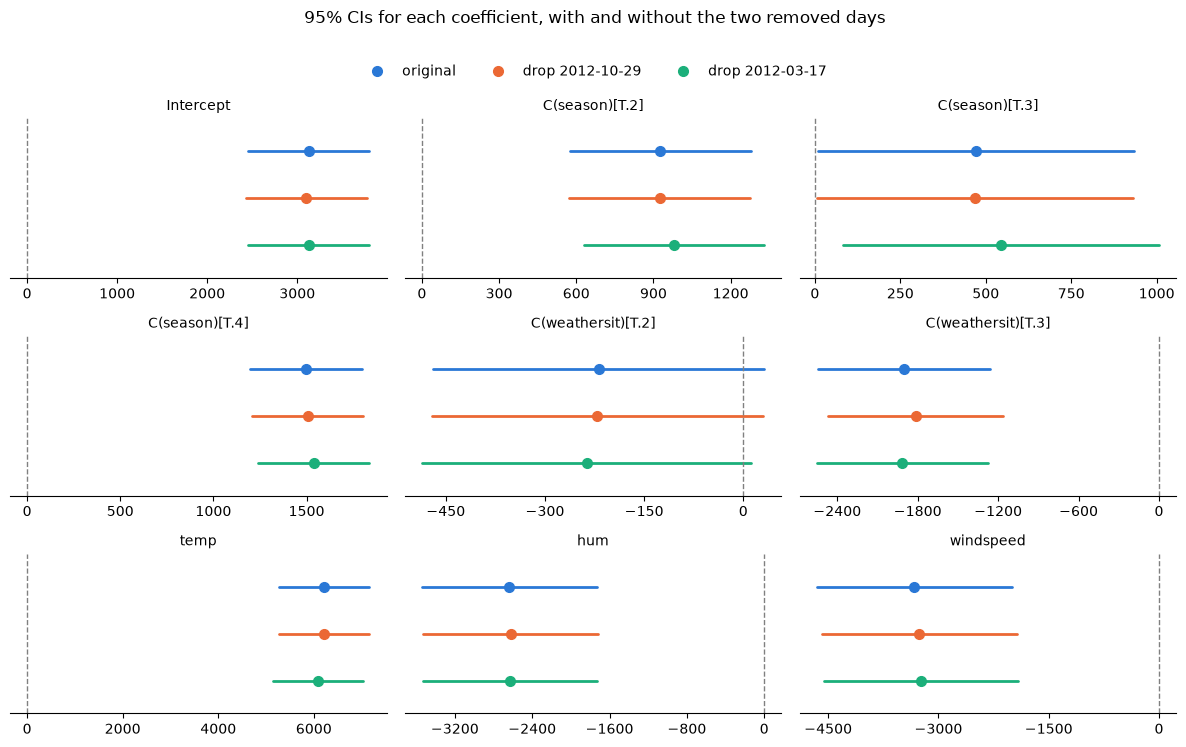

In [29]:
# We can also plot what is in these tables to more helpfully visualize it. 

colors = ["#2a78d6", "#eb6834", "#1baf7a"]
terms = list(models["original"].params.index)

fig, axes = plt.subplots(3, 3, figsize=(12, 7))
for ax, term in zip(axes.flat, terms):
    for i, ((name, m), color) in enumerate(zip(models.items(), colors)):
        low, high = m.conf_int().loc[term]
        ax.plot([low, high], [i, i], color=color, lw=2, solid_capstyle="round")
        ax.plot(m.params[term], i, "o", color=color, ms=7, label=name)
    ax.axvline(0, color="gray", lw=1, ls="--")
    ax.set_title(term, fontsize=10)
    ax.set_yticks([])
    ax.set_ylim(-0.7, 2.7)
    ax.invert_yaxis()
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
fig.suptitle("95% CIs for each coefficient, with and without the two removed days", y=1.06)
fig.tight_layout()
plt.show()

**Q2 Reflection**

If we look at the results above, we can make a few observations:
* The highest Adjusted $R^2$ value occurs when we remove the March 2012 datapoint, but all three Adjusted $R^2$ values are quite close to each other.
* While the coefficients shift slightly upon removal of either of these data points, we can see from the plot above that they do not materially impact any of the coefficients or confidence intervals. We draw the same conclusions whether these data points are included or excluded. 

This is a case where you should not remove these two datapoints. While there are clear anomalies happening (Hurricane Sandy, beautiful St. Patrick's Day), they don't impact the overall model, and there is no justification for removal. (e.g. faulty sensors, clear data input error) 

If you had a colleague or manager who was demanding you remove those data points, you could communicate the following to your stakeholders: We have removed two datapoints from our analysis that are anomalies. I have ascertained that we would draw the same conclusions whether they are included or excluded from the model. (You could also share that you recommended against removing these data points, but depending on the situation and personnel involved, you might want to leave that out.)